# Logistic Regression Model for Customer Churn

This notebook uses logistic regression to classify customer churn.

## Load and Clean Dataset (and a Note on Independence)

In [ ]:
# Load packages, ignore warnings, and define a seed for reproducibility
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report, log_loss, brier_score_loss, roc_curve, roc_auc_score, precision_recall_curve,average_precision_score)
from scipy.stats import chi2
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("default")

SEED = 42

In [2]:
# Load the dataset
data_path = Path("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_original = pd.read_csv(data_path)

df_original.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
# Check the dimensions of the dataset
print(f"Dimensions: {df_original.shape}")

Dimensions: (7043, 21)


In [33]:
# Look at the number of unique customers
# This is used to make assumptions about the validity of independence
print(f'Number of unique customers: {df_original["customerID"].nunique()}')

Number of unique customers: 7043


Since many standard techniques for exploring the independence assumption cater to linear regression and/or time-series data, we will look at independence by looking at the data directly. Given that the data is cross-sectional and there are 7043 unique customer IDs, which implies that every row represents a unique customer, it is assumed that the data is independent. Since this assumption is not being formally validated, regression statistics (like the standard error) should be interpreted cautiously.

In [4]:
# Drop the customerID column
# Since this column is just an identifier, 
# it does not give us any useful information for the analysis
df = df_original.drop(columns="customerID")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Identifier columns with missing rows 
# and the number of missing rows they have
# Missingness (in this case) is define as customers 
# that do not have any data record (NAN) or have an empty string record
def missing_report(frame):
    rows = []
    for col in frame.columns:
        na = frame[col].isna().sum()
        blank = 0
        if not pd.api.types.is_numeric_dtype(frame[col]):
            blank = frame[col].astype(str).str.strip().eq("").sum()
        rows.append((col, int(na + blank)))
    rep = pd.DataFrame(rows, columns=["variable", "missing"])
    return rep.sort_values("missing", ascending=False).reset_index(drop=True)
 
print("\nMissing values per variable (NaN and empty strings):")
print(missing_report(df).to_string(index=False))



Missing values per variable (NaN and empty strings):
        variable  missing
    TotalCharges       11
          gender        0
         Partner        0
   SeniorCitizen        0
      Dependents        0
          tenure        0
   MultipleLines        0
    PhoneService        0
  OnlineSecurity        0
    OnlineBackup        0
DeviceProtection        0
 InternetService        0
     TechSupport        0
     StreamingTV        0
        Contract        0
 StreamingMovies        0
PaperlessBilling        0
   PaymentMethod        0
  MonthlyCharges        0
           Churn        0


There appears to be 11 customers who are missing data for total charges. Since 11 is a small number compared to the sample size (7043), it is safe to remove these customers to reduce the amount of noise in the data.

In [6]:
# Drop the missing rows
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna().reset_index(drop=True)
print("\nShape after removing missing:", df.shape)


Shape after removing missing: (7032, 20)


In [7]:
# Separate and store the names of each variable type
target = "Churn"

numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
]

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]

## EDA and Assumption Checks

In [8]:
# Show summary statistics to give initial information on the numeric variables
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


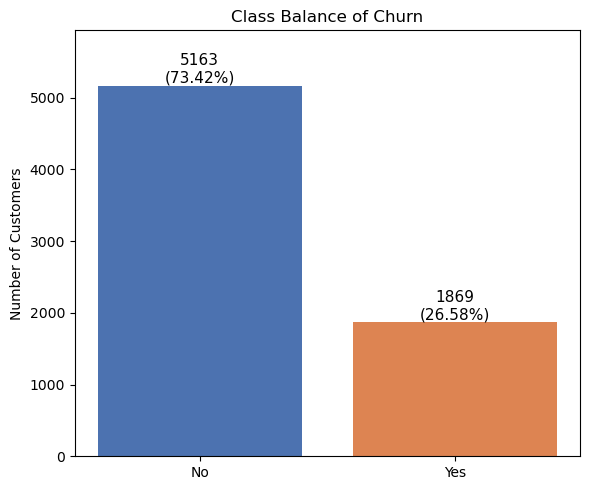

In [9]:
# Visualize churn to check class balance
counts = df[target].value_counts()
props = df[target].value_counts(normalize=True)
 
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(counts.index, counts.values, color=["#4C72B0", "#DD8452"])
for bar, cls in zip(bars, counts.index):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{counts[cls]}\n({props[cls]:.2%})",
            ha="center", va="bottom", fontsize=11)
ax.set_title("Class Balance of Churn")
ax.set_ylabel("Number of Customers")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

Churn appears to have two categories, which is good for logistic regression. However, there is a clear imbalance among the classes. Customers who were retained make up ~73% of the sample, while customers who left only make up ~27% of the sample. This is a concern because the model may struggle to predict when a customer leaves.

In [10]:
# Show the unique levels and number of levels for each categorical variable

print("\n--- Categorical predictor levels ---")

categorical_levels = []

for c in categorical_features:
    lvls = df[c].unique().tolist()

    categorical_levels.append({
        "Features": c,
        "# levels": len(lvls),
        "Levels": lvls
    })

categorical_levels_df = pd.DataFrame(categorical_levels)

print(categorical_levels_df.to_string(index=False))



--- Categorical predictor levels ---
        Features  # levels                                                                               Levels
          gender         2                                                                       [Female, Male]
   SeniorCitizen         2                                                                               [0, 1]
         Partner         2                                                                            [Yes, No]
      Dependents         2                                                                            [No, Yes]
    PhoneService         2                                                                            [No, Yes]
   MultipleLines         3                                                          [No phone service, No, Yes]
 InternetService         3                                                               [DSL, Fiber optic, No]
  OnlineSecurity         3                                        

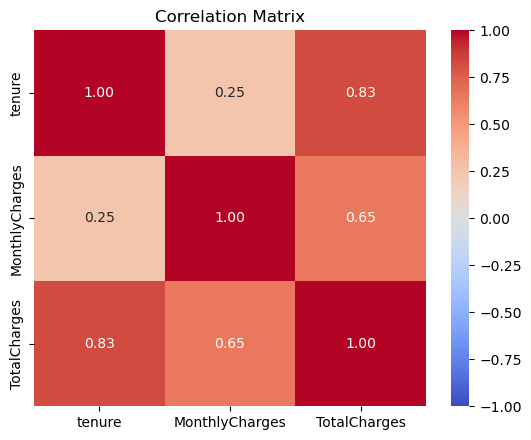

In [11]:
# Create a correlation matrix to explore multicollinearity
corr = df[numeric_features].corr()
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Customer tenure and total charges seem to have a strong correlation with each other. This is an understandable association since customers who have been with the company longer are more likely to incur more costs compared to a newer customer just by using the services the company provides for a longer period of time. Since keeping both variables does not provide us with much additional information and unnecessarily increases the dimensionality of the data, it would be beneficial to remove one of them.

In [12]:
# Obtain the data needed for VIF
# The numeric variables remain unchanged and 
# the categorical variables are encoded
num_df = df[numeric_features].copy()

encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

cat_arr = encoder.fit_transform(
    df[categorical_features]
)

cat_df = pd.DataFrame(
    cat_arr,
    columns=encoder.get_feature_names_out(
        categorical_features
    ),
    index=df.index
)

In [13]:
# Calculate the VIF to explore multicollinearity
# Variables with VIF > 5 have high multicollinearity,
# and variables with VIF > 10 have extremely high multicollinearity
X_vif = pd.concat(
    [
        num_df,
        cat_df
    ],
    axis=1
)

X_vif = X_vif.astype(float)

def vif_table(X):

    rows = []

    for i, col in enumerate(X.columns):

        rows.append(
            (
                col,
                variance_inflation_factor(
                    X.values,
                    i
                )
            )
        )

    return (
        pd.DataFrame(
            rows,
            columns=["feature", "VIF"]
        )
        .sort_values(
            "VIF",
            ascending=False
        )
        .reset_index(drop=True)
    )

vif = vif_table(
    X_vif
)

print("\n")
print("=" * 80)
print("VIF")
print("=" * 80)

print(
    vif.head(10).to_string(index=False)
)

c:\Users\mysty\miniforge3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)




VIF
                             feature         VIF
                  InternetService_No         inf
  OnlineSecurity_No internet service         inf
     TechSupport_No internet service         inf
     StreamingTV_No internet service         inf
DeviceProtection_No internet service         inf
    OnlineBackup_No internet service         inf
 StreamingMovies_No internet service         inf
                    PhoneService_Yes 1773.528816
                      MonthlyCharges  866.089640
         InternetService_Fiber optic  148.500814


There seems to be extremely high multillinearity among some of the service variable. One potential reason for this is that these variables have categories with overlapping information, such as "No" and "No internet service". Condensing these categories could be helpful since they remove an uninformative variable, which reduces dimensionality. Another potential fix is to remove the total charges variable, since it is highly correlated to tenure and it has a higher vif score than tenure, which implies that it may be strongly correlated with other predictors.

In [14]:
# Collapse similar categories in the service variables 
# and drop total charges to reduce multicollinearity
df = df.drop(columns=["TotalCharges"])

services = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

df[services] = df[services].replace(
    "No internet service", "No"
)

df["MultipleLines"] = df["MultipleLines"].replace(
    "No phone service", "No"
)

numeric_features_final = [
    "tenure",
    "MonthlyCharges",
]

cat_arr_final = encoder.transform(
    df[categorical_features]
)

cat_df_final = pd.DataFrame(
    cat_arr_final,
    columns=encoder.get_feature_names_out(
        categorical_features
    ),
    index=df.index
)

In [15]:
# Calculate VIF again to see if multicollinearity was reduced
X_vif_2 = pd.concat(
    [
        df[numeric_features_final].copy(),
        cat_df_final
    ],
    axis=1
)

X_vif_2 = X_vif_2.astype(float)

vif_2 = vif_table(
    X_vif_2
)

print("\n")
print("=" * 80)
print("VIF 2 (TotalCharges removed)")
print("=" * 80)

print(
    vif_2.head(10).to_string(index=False)
)

print("\n")
print("=" * 80)
print("\nVIF summary:")
print("=" * 80)

print(
    f"Maximum VIF before removing TotalCharges: "
    f"{vif['VIF'].max():.3f}"
)

print(
    f"Maximum VIF after removing TotalCharges: "
    f"{vif_2['VIF'].max():.3f}"
)

c:\Users\mysty\miniforge3\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss




VIF 2 (TotalCharges removed)
                       feature        VIF
                MonthlyCharges 179.115134
              PhoneService_Yes  41.864738
   InternetService_Fiber optic  12.992621
                        tenure   7.754377
            InternetService_No   6.743132
           StreamingMovies_Yes   4.268254
               StreamingTV_Yes   4.132248
             Contract_Two year   3.463161
          PaperlessBilling_Yes   2.956462
PaymentMethod_Electronic check   2.949641



VIF summary:
Maximum VIF before removing TotalCharges: inf
Maximum VIF after removing TotalCharges: 179.115


Converting the service variables to binary variables and removing the total charges variable seems to have reduce multicollinearity. While there still seems to be a large amount of multicollinearity given the VIF of ~179, the improvement is noteworthy.

In [16]:
# Scale the numeric variables so they can have similar influence on the model
# Variables with larger values tend to have larger influence, and scaling counters this
scaler = StandardScaler()

num_arr_scaled_final = scaler.fit_transform(
    df[numeric_features_final]
)

num_df_scaled_final = pd.DataFrame(
    num_arr_scaled_final,
    columns=numeric_features_final,
    index=df.index
)

In [17]:
# Create the final predictor matrix
X_final = pd.concat(
    [
        num_df_scaled_final,
        cat_df_final
    ],
    axis=1
)

X_final = X_final.astype(float)

print(f"Predictor Matrix Dimensions: {X_final.shape}")
X_final.head(10)

Predictor Matrix Dimensions: (7032, 29)


,tenure,MonthlyCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-1.280248,-1.161694,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.064303,-0.260878,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-1.239504,-0.363923,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.512486,-0.747850,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,-1.239504,0.196178,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
5,-0.995040,1.158489,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
6,-0.424625,0.807802,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
7,-0.913552,-1.165018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8,-0.180161,1.329677,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
9,1.205134,-0.287470,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [18]:
# Create the output vector
y = (
    df[target] == "Yes"
).astype(int)

In [19]:
# Add a constant to the predictor matrix
# This constant serves as the intercept, 
# and making so the model does not go through 0
# This helps produce more realistic regression statistics
X_sm = sm.add_constant(
    X_final,
    has_constant="add"
).astype(float)

In [20]:
# Perform logistic regression using statsmodels
# This is only for initial exploration, as well 
# as to check the linearity and influence assumptions
stats_model = sm.GLM(
    y,
    X_sm,
    family=sm.families.Binomial()
)

stats_result = stats_model.fit()


print("\n")
print("=" * 80)
print("STATSMODELS LOGISTIC REGRESSION")
print("=" * 80)

print(
    stats_result.summary()
)



STATSMODELS LOGISTIC REGRESSION
                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Churn   No. Observations:                 7032
Model:                            GLM   Df Residuals:                     7009
Model Family:                Binomial   Df Model:                           22
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2924.5
Date:                Thu, 03 Sep 2026   Deviance:                       5849.1
Time:                        12:09:48   Pearson chi2:                 7.18e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2784
Covariance Type:            nonrobust                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

In [21]:
# Create a table that contains the original coefficients, the odds ratios, the p values, and the confidence intervals
odds_ratios = pd.DataFrame({

    "feature":
        stats_result.params.index,

    "coefficient":
        stats_result.params.values,

    "odds_ratio":
        np.exp(
            stats_result.params.values
        ),

    "p_value":
        stats_result.pvalues.values,

    "CI_lower":
        np.exp(
            stats_result.conf_int()[0].values
        ),

    "CI_upper":
        np.exp(
            stats_result.conf_int()[1].values
        ),
})


print("\nOdds ratios:")

print(
    odds_ratios.to_string(
        index=False
    )
)


Odds ratios:
                              feature   coefficient  odds_ratio      p_value  CI_lower  CI_upper
                                const -2.613726e+00    0.073261 4.170941e-02  0.005920  0.906544
                               tenure -8.439911e-01    0.429991 1.953753e-47  0.383532  0.482078
                       MonthlyCharges -9.790675e-01    0.375661 3.086148e-01  0.057050  2.473646
                          gender_Male -2.055736e-02    0.979652 7.514080e-01  0.862649  1.112526
                      SeniorCitizen_1  2.181026e-01    1.243715 1.022846e-02  1.052998  1.468973
                          Partner_Yes -9.882979e-04    0.999012 9.898603e-01  0.857780  1.163498
                       Dependents_Yes -1.640267e-01    0.848719 6.739457e-02  0.711916  1.011811
                     PhoneService_Yes  1.601135e-01    1.173644 8.063413e-01  0.326282  4.221629
       MultipleLines_No phone service  2.667506e-15    1.000000 9.957286e-02  1.000000  1.000000
                

In [22]:
# Check linearity with the Box-Tidwell Test
# If the p value is < 0.05, the linearity assumption has been violated
print("\n")
print("=" * 80)
print("BOX-TIDWELL TEST — LINEARITY OF THE LOGIT")
print("=" * 80)

bt = df[
    numeric_features_final
].copy()


for c in numeric_features_final:

    # Handle possible zero values.
    x_positive = bt[c].clip(
        lower=1e-8
    )

    bt[f"{c}_ln"] = (
        x_positive
        * np.log(x_positive)
    )

bt_design = pd.concat(
    [
        bt,
        cat_df
    ],
    axis=1
)

bt_design = sm.add_constant(
    bt_design,
    has_constant="add"
).astype(float)

bt_model = sm.GLM(
    y,
    bt_design,
    family=sm.families.Binomial()
)

bt_result = bt_model.fit()

for c in numeric_features_final:

    term = f"{c}_ln"

    p_value = bt_result.pvalues[term]

    if p_value < 0.05:

        conclusion = "NON-LINEAR"

    else:

        conclusion = "ok (linear)"

    print(
        f"{c}: "
        f"interaction p={p_value:.4g} "
        f"-> {conclusion}"
    )



BOX-TIDWELL TEST — LINEARITY OF THE LOGIT


tenure: interaction p=1.307e-20 -> NON-LINEAR
MonthlyCharges: interaction p=0.1221 -> ok (linear)


Based on the Box-Tidwell test, there seems to be a violation in linearity for tenure. Tenure does not have a linear relationship with the log-odds of churn. Thus, we need to be mindful when interpreting the coefficients since they may not be the most reliable.

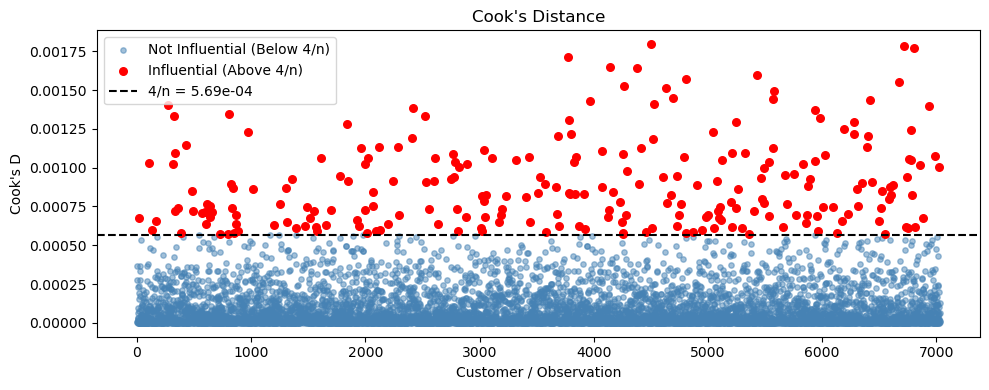


Cook's distance: 242 observations above the 4/n threshold (3.4% of data)
Maximum Cook's D = 0.0018


In [23]:
infl = stats_result.get_influence()

cooks = infl.cooks_distance[0]

threshold = 4 / len(cooks)

n_infl = int(
    (cooks > threshold).sum()
)

obs = np.arange(len(cooks))

influential = cooks > threshold

plt.figure(
    figsize=(10, 4)
)

plt.scatter(
    obs[~influential],
    cooks[~influential],
    s=15,
    alpha=0.5,
    color="steelblue",
    label="Not Influential (Below 4/n)"
)

plt.scatter(
    obs[influential],
    cooks[influential],
    s=30,
    color="red",
    label="Influential (Above 4/n)"
)

plt.axhline(
    threshold,
    color="black",
    linestyle="--",
    label=f"4/n = {threshold:.2e}"
)

plt.title(
    "Cook's Distance"
)

plt.xlabel(
    "Customer / Observation"
)

plt.ylabel(
    "Cook's D"
)

plt.legend()

plt.tight_layout()

plt.show()

print(
    f"\nCook's distance: "
    f"{n_infl} observations above the 4/n threshold "
    f"({n_infl / len(cooks):.1%} of data)"
)

print(
    f"Maximum Cook's D = {cooks.max():.4f}"
)


Based on the threshold of 4 / sample size (7043), there seems to be 242 influential customers. Since this is a small portion of the sample (~3.4%), the results are more likely to be stable.

## Logistic Regression Model Fit and Performance Evidence

In [24]:
# Preform logistic regression using the Sklearn model to predict churn
# The decision boundary is at 0.5
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)


X_train = X_train.copy()
X_test = X_test.copy()

X_train[numeric_features_final] = scaler.fit_transform(
    X_train[numeric_features_final]
)

X_test[numeric_features_final] = scaler.transform(
    X_test[numeric_features_final]
)


sk_model = LogisticRegression(
    random_state=SEED,
    max_iter=1000
)

sk_model.fit(
    X_train,
    y_train
)


pred_proba = sk_model.predict_proba(
    X_test
)[:, 1]

y_pred = (
    pred_proba >= 0.50
).astype(int)



SKLEARN LOGISTIC REGRESSION — PREDICTIVE PERFORMANCE


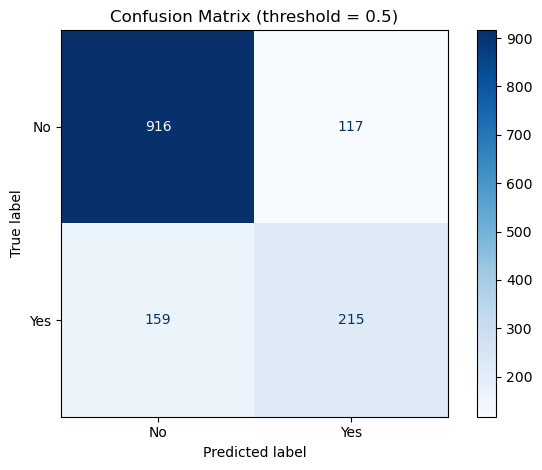


Classification report:
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

Cross-entropy (log loss): 0.4293
Brier score            : 0.1407
ROC-AUC                : 0.8337
PR-AUC (average precision): 0.619


In [ ]:
# Show the performance of the model

print("\n")
print("=" * 80)
print("SKLEARN LOGISTIC REGRESSION — PREDICTIVE PERFORMANCE")
print("=" * 80)


cm = confusion_matrix(
    y_test,
    y_pred
)


ConfusionMatrixDisplay(
    cm,
    display_labels=["No", "Yes"]
).plot(
    cmap="Blues"
)


plt.title(
    "Confusion Matrix (threshold = 0.5)"
)

plt.tight_layout()

# plt.savefig(
#     "confusion_matrix.png",
#     dpi=120
# )

# plt.close()
plt.show()

print("\nClassification report:")

print(
    classification_report(
    y_test,
    y_pred,
    target_names=["No", "Yes"]
)
)

logloss = log_loss(
    y_test,
    pred_proba
)

brier = brier_score_loss(
    y_test,
    pred_proba
)

roc_auc = roc_auc_score(
    y_test,
    pred_proba
)

pr_auc = average_precision_score(
    y_test,
    pred_proba
)


print(
    "Cross-entropy (log loss):",
    round(logloss, 4)
)

print(
    "Brier score            :",
    round(brier, 4)
)

print(
    "ROC-AUC                :",
    round(roc_auc, 4)
)

print(
    "PR-AUC (average precision):",
    round(pr_auc, 4)
)

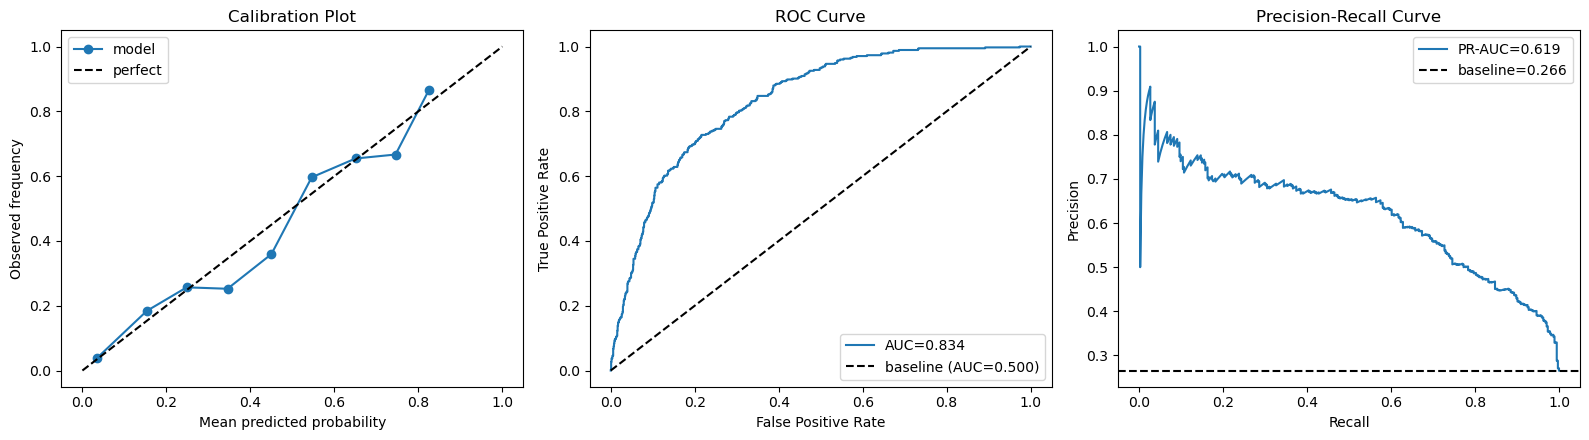

In [26]:
# Visualize model performance

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.5)
)

frac_pos, mean_pred = calibration_curve(
    y_test,
    pred_proba,
    n_bins=10
)


axes[0].plot(
    mean_pred,
    frac_pos,
    "o-",
    label="model"
)

axes[0].plot(
    [0, 1],
    [0, 1],
    "k--",
    label="perfect"
)

axes[0].set_title(
    "Calibration Plot"
)

axes[0].set_xlabel(
    "Mean predicted probability"
)

axes[0].set_ylabel(
    "Observed frequency"
)

axes[0].legend()


fpr, tpr, _ = roc_curve(
    y_test,
    pred_proba
)


axes[1].plot(
    fpr,
    tpr,
    label=f"AUC={roc_auc:.3f}"
)

axes[1].plot(
    [0, 1],
    [0, 1],
    "k--",
    label="baseline (AUC=0.500)"
)

axes[1].set_title(
    "ROC Curve"
)

axes[1].set_xlabel(
    "False Positive Rate"
)

axes[1].set_ylabel(
    "True Positive Rate"
)

axes[1].legend()

precision, recall, _ = precision_recall_curve(
    y_test,
    pred_proba
)


axes[2].plot(
    recall,
    precision,
    label=f"PR-AUC={pr_auc:.3f}"
)

axes[2].axhline(
    y_test.mean(),
    ls="--",
    color="k",
    label=f"baseline={y.mean():.3f}"
)

axes[2].set_title(
    "Precision-Recall Curve"
)

axes[2].set_xlabel(
    "Recall"
)

axes[2].set_ylabel(
    "Precision"
)

axes[2].legend()


plt.tight_layout()

# plt.savefig(
#     "performance_curves.png",
#     dpi=120
# )

#plt.close()

plt.show()

The logistic regression model demonstrates good overall predictive performance, achieving 80% accuracy and a strong ROC-AUC of 0.834, indicating a good ability to distinguish between customers who are likely to stay and those who are likely to leave. The model is particularly good at identifying customers who stay (89% recall), while its performance in identifying customers who leave is more moderate, which 65% precision and 57% recall. Despite the moderate performance, the PR-AUC of 0.619, which is substantially above the 0.266 baseline, indicates that the model has useful predictive ability for identifying customers at risk of leaving. Overall, the model provides a solid foundation for predicting customer retention, although improving its ability to identify customers who leave could make it more effective for targeted retention efforts.

## Coefficients, Odds-Ratios, and Interpretations

In [27]:
# Obtain the coefficients and odds-ratios for interpretation
sk_coefficients = pd.DataFrame({

    "feature": X_train.columns,

    "coefficient":
        sk_model.coef_[0],

    "odds_ratio":
        np.exp(
            sk_model.coef_[0]
        )
})


sk_coefficients = (
    sk_coefficients
    .sort_values(
        "coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nSklearn model coefficients:")

print(
    sk_coefficients.to_string(
        index=False
    )
)


Sklearn model coefficients:
                              feature  coefficient  odds_ratio
          InternetService_Fiber optic     1.037234    2.821403
       PaymentMethod_Electronic check     0.388065    1.474126
                    MultipleLines_Yes     0.366482    1.442651
                      StreamingTV_Yes     0.356030    1.427650
                  StreamingMovies_Yes     0.329320    1.390023
                 PaperlessBilling_Yes     0.289589    1.335879
                      SeniorCitizen_1     0.193015    1.212900
           PaymentMethod_Mailed check     0.114295    1.121083
                 DeviceProtection_Yes     0.076967    1.080006
PaymentMethod_Credit card (automatic)     0.037111    1.037809
 DeviceProtection_No internet service     0.000000    1.000000
       MultipleLines_No phone service     0.000000    1.000000
   OnlineSecurity_No internet service     0.000000    1.000000
     OnlineBackup_No internet service     0.000000    1.000000
  StreamingMovies_No inter

Reiterating from the Box-Tidwell test, since tenure is not linear, we need to be careful when interpreting these coefficients. That said, from the table of coefficients and odds ratios, we can see that when all other variables are held constant, the odds of a customer leaving is ~2.82 times higher for customers with fiber optic as their internet service provider compared to customers with DSL as their internet service provider. On the other hand, the odds of a customer leaving is ~0.39 times higher for customers who do not have an internet service provider (at least not with this company) compared to customers with DSL as their internet service provider, when all other variables are held constant. Another piece of information we see is with every month a customer stays with the company, the odds that they will leave increases by ~0.45 times when all other variables are held constant. We also see that as a customer's bill increases (presumably by a dollar) their odds of leaving increases by ~0.85 times.

# Limitation of Logistic Regression 

Logistic regression encounters a huge barrier when the classes are imbalanced. Churn data tends to have a larger portion of customers who stay compared to customers who leave. This pattern is even reflected in this analysis with ~73% of customers retained and ~27% of customers churned. Whenever a class imbalance is present, logistic regression tends to predict the majority class more often than it should to minimize the penalty from cross entropy lost (the metric it is trying to minimize). This can lead the model to produce an artificially high accuracy despite struggling to accurately predict the minority class.